In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
!pip install gensim
!pip install scikit-learn
!pip install numpy
!pip install pandas
!pip install tensorflow
!pip install torch
!pip install emoji
!pip install nlpaug

In [31]:
# file management
import zipfile
from pathlib import Path

# dataframe management
import pandas as pd
import json

# data manipulation
import numpy as np

#
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# typing
from typing import List, Callable, Dict
from collections import OrderedDict

#
import re

# text augmentation
import nlpaug.augmenter.word as naw
#Lemmatization
import nltk
from nltk.tokenize import (word_tokenize,
 sent_tokenize,
 WhitespaceTokenizer)
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

# Embedding models
import gensim
import gensim.downloader as gloader


def extract_dataset(download_path: Path, extract_path: Path):
    print("Extracting dataset... (it may take a while...)")

    if download_path.suffix == ".zip":
        with zipfile.ZipFile(download_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
    else:
        raise ValueError(f"Unsupported file format: {download_path.suffix}")
    print("Extraction completed!")

dataset_name = "EXIST"
#File location
download_path =  Path.home() / "Downloads" / "A1.zip"
print(f"Current work directory: {Path.cwd()}")
dataset_folder = Path.cwd().joinpath("Datasets")

Current work directory: /content


In [32]:

import json

base_path = "/content/drive/MyDrive/A1/data/"

with open(base_path + 'training.json', 'r', encoding='utf-8') as f:
    training_data = json.load(f)

with open(base_path + 'validation.json', 'r', encoding='utf-8') as f:
    validation_data = json.load(f)

with open(base_path + 'test.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print("Loaded JSON files successfully!")
print("Train size:", len(training_data))
print("Validation size:", len(validation_data))
print("Test size:", len(test_data))

Loaded JSON files successfully!
Train size: 6920
Validation size: 726
Test size: 312


In [33]:
import pandas as pd
import numpy as np

df_train = pd.DataFrame(training_data).T
df_test = pd.DataFrame(test_data).T
df_validation = pd.DataFrame(validation_data).T

def mode_modified(x):
    a = pd.Series(x).mode().to_list()
    if len(a) > 1:
        return np.nan
    else:
        return a[0]

# Apply to df_train
df_train['labels_task2'] = df_train['labels_task2'].apply(mode_modified)
df_train.rename(columns={'labels_task2': 'label'}, inplace=True)
df_train.dropna(axis=0, how='any', inplace=True)

# Apply to df_validation
df_validation['labels_task2'] = df_validation['labels_task2'].apply(mode_modified)
df_validation.rename(columns={'labels_task2': 'label'}, inplace=True)
df_validation.dropna(axis=0, how='any', inplace=True)

# Apply to df_test
df_test['labels_task2'] = df_test['labels_task2'].apply(mode_modified)
df_test.rename(columns={'labels_task2': 'label'}, inplace=True)
df_test.dropna(axis=0, how='any', inplace=True)

# Filter for lang == 'en'
df_train = df_train[df_train['lang'] == 'en'].copy()
df_validation = df_validation[df_validation['lang'] == 'en'].copy()
df_test = df_test[df_test['lang'] == 'en'].copy()

# Removing unnecessary columns
removed_columns = ['number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task3', 'split']
df_train.drop(columns=removed_columns, inplace=True)
df_validation.drop(columns=removed_columns, inplace=True)
df_test.drop(columns=removed_columns, inplace=True)

# Converting the types of columns
df_train = df_train.convert_dtypes()
df_validation = df_validation.convert_dtypes()
df_test = df_test.convert_dtypes()

# Encoding the label column
categories = ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']
df_train['label'] = pd.CategoricalIndex(df_train['label'], categories=categories).codes
df_validation['label'] = pd.CategoricalIndex(df_validation['label'], categories=categories).codes
df_test['label'] = pd.CategoricalIndex(df_test['label'], categories=categories).codes

In [ ]:
#Removing emojis
import emoji
import re
import nltk
from nltk.tokenize import (word_tokenize, sent_tokenize, WhitespaceTokenizer)
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

# Apply to df_train, df_validation, df_test
for df in [df_train, df_validation, df_test]:
    df['tweet'] = df['tweet'].astype(str)
    df['tweet'] = df['tweet'].apply(lambda x: emoji.replace_emoji(x, replace = ' '))

#Expand contractions
contraction_patterns = [ (r'\bwon\'t\b', 'will not'), (r'\bcan\'t\b', 'can not'), (r'\bi\'m\b', 'i am'), (r'(\w+)\'ll', r'\1 will'),
                         (r'(\w+)\'ve', r'\1 have'),(r"\b(he|she|it|that|there|what|where|who|when|why)'s\b",r"\1 is"), (r'(\w+)\'re', r'\1 are'),
                         (r'\bdammit\b', 'damn it'), (r"\bi ain't\b", "i am not"), (r"\bshe ain't\b","she is not"),(r'(\w+)\'d', r'\1 would'), (r'\b&\b', 'and'),
                         (r"\b(we|you|they)\s+ain't\s+(done|seen|been|got)\b",r"\1 have not \2"), (r"\b(he|she|it)\s+ain't\s+(done|seen|been|got)\b",r"\1 has not \2"),
                         (r"\b(he|she|it)\s+ ain't\b",r"\1 is not"), (r"\b(we|you|they)\s+ ain't\b",r"\1 are not"),
                         (r'\bdont\b','do not'),(r"\blet's\b","let us"),(r'\bdoesnt\b','does not'),
                         (r"\bdon't\b", "do not") ,(r"\bdoesn't\b", "does not"),(r"didn't", "did not"), (r"\bcan't\b", "can not"),
                         (r"\bwont\b", "will not"),(r"\bisn't\b", "is not"), (r"\baren't\b","are not"),(r"\bwasn't\b","was not"),
                         (r"\baren't\b","are not"),(r"\bwasn't\b","was not"), (r"\bweren't\b","were not"),(r"\bhaven't\b","have not"),
                         (r"\bhasn't\b","has not"),(r"\bhadn't\b","had not"),(r"\bshan't\b","shall not"),(r"\bwon't","will not"),(r"\bwouldnt\b","would not"),
                         (r"\bcant\b","can not"),(r"\by'all\b","you all"),(r'\bisnt\b','is not'),(r'\bhavent\b','have not'),(r'\bwasnt\b','was not')
                         ]

def clean_text (text):
  """
    Cleanse tweets by converting to lower case, normalise and remove
    empty items.

    Arguments:
        text {str} -- Extracted "dirty" tweets
    Returns:
        text {str} -- Cleansed tweets
  """
  # Filter hashtag #
  text = re.sub(r"#\S+|\s#\s|\s#$|^#\s",'',text)
  # Remove mentions @
  text = re.sub(r"@\S+|\s@$|\s@\s|^@\s",'',text)
  # Remove URLs
  text = re.sub(r'https?://\S+|www\.\S+',' ',text)
  # Transform single curly quotes into simples ones
  text = re.sub(r"[\u2018\u2019]","'",text)
  # Remove special characters and symbols
  text = re.sub(r"[^a-zA-Z0-9' ]",' ',text)
  # Remove quotes
  text = re.sub(r"(?=\s|^)'|(?<!\w)'(?<!\w)|'(?=\s|$)", " ", text)
  # Lower text
  text = text.lower()
  # Expand contractions
  for pattern,replacement in contraction_patterns:
         text = re.sub(pattern,replacement,text, flags = re.IGNORECASE)
  # Eliminate remaining simple quotes
  text = re.sub(r"'",' ',text)
  # Substitute multiple spaces with one space
  text = re.sub(r"\s+|^\s+|\s+$", " ", text)
  return text

for df in [df_train, df_validation, df_test]:
    df['tweet'] = df['tweet'].apply(lambda x: clean_text(x))

""" Creates a dictionary with slangs and their equivalents and replaces them """
slang_map = {}
path = "/content/drive/MyDrive/Colab Notebooks/custom_slang.txt"
with open(path,'r',encoding='utf-8-sig') as file:
    for line in file:
         if line.strip():
            parts = line.strip().split(maxsplit=1)
            key, val  = parts
            slang_map[key.strip().lower()] = val.strip()
slang_words = sorted(slang_map, key=len, reverse=True) # longest first for regex

def replace_slang(match):
    key = match.group().lower()
    return slang_map.get(key, match.group())
rare_stopwords = {
    "meanwhile","therefore","moreover","however","ah",
    "otherwise","nonetheless","likewise","whilst","rt","via",
    "afterwards","eventually","previously","currently","recently","lately",
    "elsewhere","somewhere","nowhere","etc","et","al","bla","blah"
}

def tweet_specific_cleaning(df):
    """
    Cleanse tweets by performing the following steps:
    - remove stopwords
    - slang normalization
    - map numbers into NUM token
    - remove white spaces
    Arguments:
        text {str} -- preprocessed tweets
    Returns:
        text {str} -- cleansed tweets
    """
    df = df.copy()
    # Remove stopwords
    stopwords_pattern = r'\b(?:' + '|'.join(map(re.escape, rare_stopwords)) + r')\b'
    df['tweet'] = df['tweet'].apply(lambda x: re.sub(stopwords_pattern, '',x, flags=re.IGNORECASE))
    # Slang normalization
    slang_pattern = re.compile(r"\b(" + "|".join(map(re.escape, slang_map.keys())) + r")\b", flags=re.IGNORECASE)
    df['tweet'] = df['tweet'].apply(lambda x: slang_pattern.sub(replace_slang, x))
    # Numbers are mapped into a NUM token
    df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'\b\d+\b', '<NUM>', x))
    # Remove white spaces
    df['tweet'] = df['tweet'].apply(lambda x :re.sub(r'\s+', ' ', x).strip())
    return df

#Lemmatization
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

tokenizer = WhitespaceTokenizer()
lemmatizer = nltk.stem.WordNetLemmatizer()

def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'
def lem_text(df, text_col='tweet'):
    """
    Applies lemmatization to the column text_col of the  DataFrame df.

    Args:
        df (pd.DataFrame): DataFrame with a text column
        text_col (str): name of the text column (default 'tweet')

    Returns:
        pd.DataFrame: DataFrame with the lemmatized column
    """
    df = df.copy()

    def lemmatize_text(text):
        if not isinstance(text, str):
            return ''
        tokens = tokenizer.tokenize(text)
        tagged = pos_tag(tokens)
        words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
        return " ".join(words)

    df[text_col] = df[text_col].apply(lambda x: lemmatize_text(x))
    return df


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [35]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")

    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model
embedding_dimension = 100

embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=embedding_dimension)

In [36]:

def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing: List[str]):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

# SAFE TWITTER-BASED DATA AUGMENTATION
import random
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

aug = naw.ContextualWordEmbsAug(
    model_path='bert-base-uncased',
    action='substitute',
    aug_max = 3,
    aug_p=0.3,
    stopwords=stop_words,
    top_k=5,
    device='cuda'
)

def twitter_augment(text):
    out = aug.augment(text)
    return out[0] if isinstance(out,list) else out

# y labels (moved before augmentation)

y_val = df_validation['label'].values
y_test = df_test['label'].values
# Random seed for np.random.uniform
seed = 42
random.seed(seed)
np.random.seed(seed)
y_train = df_train['label'].values
y_validation = df_validation['label'].values
y_test = df_test['label'].values
def tweet_augmentation(df_train, augment_minority = 0.30, augment_majority = 0.5):
  """
  Augment tweets in a training DataFrame.
  :param df_train: dataset to be augmented (pd.DataFrame)
  :param augment_minority: percentage of tweets of the minority classes to be augmented (float)
  :param augment_majority: percentage of tweets of the class  0 to be augmented (float)

  :return
     -df_train: augmented dataframe (pd.DataFrame)
     -y_train: augmented labels (np.ndarray)
  """
  df_train = df_train.copy()
  y_train = df_train['label'].values

  augmented_tweets = []
  augmented_labels = []

  minority_class = [1,2,3]

  for tweet, label in zip(df_train['tweet'], y_train):
    if label in minority_class and random.random() < augment_minority:  # augment 30% of tweets
        new_tweet = twitter_augment(tweet)
        augmented_tweets.append(new_tweet)
        augmented_labels.append(label)
    elif label not in minority_class and random.random() < augment_majority:
        new_tweet = twitter_augment(tweet)
        augmented_tweets.append(new_tweet)
        augmented_labels.append(label)
  df_aug = pd.DataFrame({"tweet": augmented_tweets, "label": augmented_labels})
  # Combine with original training data
  df_train = pd.concat([df_train, df_aug], ignore_index=True)
  y_train = np.concatenate([y_train, np.array(augmented_labels)], axis=0)
  return df_train,y_train

def run_pipeline (df, pipeline):
    y = None
    for step in pipeline:
      if "tweet_augmentation" in step.__name__:
        df,y = step(df)
      else:
        df = step(df)
    return df,y
#BILSTM PIPELINE
pipeline_bilstm = [
    tweet_augmentation,lem_text, tweet_specific_cleaning
    ]
pipeline_bval = [
    lem_text,tweet_specific_cleaning
    ]
df_train_bilstm,y_train_bilstm = run_pipeline(df_train,pipeline_bilstm)
df_validation_bilstm,_ = run_pipeline(df_validation,pipeline_bval)
df_test_bilstm,_ = run_pipeline(df_test,pipeline_bval)

def build_tokenization(df_train,df_validation,df_test,text_column = 'tweet',MAX_LEN = 60): #MAX_LEN = embedding dimension
    """
    Tokenization of a text column of a dataframe
    : param df_train:  training DataFrame
    : param df_validation: validation DataFrame
    : param df_test: test DataFrame
    : text_column:   name of the column containing the text
    : MAX_LEN: maximum sequence length
    Return:
    - X_train: padded token sequences for training set
    - X_val: padded token sequences for validation set
    - X_test: padded token sequences for test set
    - tokenizer fitted Keras tokenizer instance
    """
    tokenizer = Tokenizer(oov_token = "<OOV>")

    tokenizer.fit_on_texts(df_train[text_column])

    X_train= tokenizer.texts_to_sequences(df_train[text_column])
    X_val = tokenizer.texts_to_sequences(df_validation[text_column])
    X_test = tokenizer.texts_to_sequences(df_test[text_column])

    X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
    X_val   = pad_sequences(X_val,   maxlen=MAX_LEN, padding='post', truncating='post')
    X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

    print(f"X_train shape: {X_train.shape}, y_train shape: {df_train['label'].values.shape}")
    print(f"X_val shape: {X_val.shape}, y_val shape: {df_validation['label'].values.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {df_test['label'].values.shape}")
    return X_train,X_val,X_test,tokenizer

X_train_bilstm,X_val_bilstm,X_test_bilstm,tokenizer = build_tokenization(df_train_bilstm,df_validation_bilstm,df_test_bilstm)
y_train_bilstm = df_train_bilstm['label'].values
y_val_bilstm = df_validation_bilstm['label'].values
y_test_bilstm = df_test_bilstm['label'].values
word_index = tokenizer.word_index
oov_terms = check_OOV_terms(embedding_model, word_index)

def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str]) -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given
    a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector
        to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in word_to_idx.items():
        try:
            embedding_vector = embedding_model[word]
        except (KeyError, TypeError):
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
    return embedding_matrix

#
embedding_matrix = build_embedding_matrix(embedding_model = embedding_model,
                                          embedding_dimension = embedding_dimension,
                                          word_to_idx = word_index,
                                          vocab_size = len(word_index)+1,
                                          oov_terms = oov_terms)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


X_train shape: (4140, 60), y_train shape: (4140,)
X_val shape: (150, 60), y_val shape: (150,)
X_test shape: (280, 60), y_test shape: (280,)


In [37]:
X_train_bilstm, X_val_bilstm, X_test_bilstm
y_train_bilstm, y_val_bilstm, y_test_bilstm
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.01254599,  0.04507143,  0.02319939, ..., -0.0072459 ,
        -0.04745809, -0.03921086],
       [-0.46953   ,  0.38432   ,  0.54833   , ..., -0.68914   ,
         0.4511    ,  0.25125   ],
       ...,
       [-0.036495  , -0.26487   , -0.21038   , ..., -0.077549  ,
        -1.1088    ,  0.57851   ],
       [ 0.23642   ,  0.42495   , -0.89063   , ..., -0.20205   ,
        -0.66418   , -0.13149   ],
       [-0.44718   ,  0.32699   , -0.05241   , ...,  0.241     ,
        -0.25679   , -0.2778    ]], dtype=float32)

In [38]:
# IMPORTS & SETUP
import numpy as np, random, tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score, precision_score, recall_score

In [39]:
# CONFIRM SHAPES
print("X_train shape:", X_train_bilstm.shape)
print("X_val shape:", X_val_bilstm.shape)
print("X_test shape:", X_test_bilstm.shape)
print("y_train shape:", y_train_bilstm.shape)
print("Embedding matrix shape:", embedding_matrix.shape)

X_train shape: (4140, 60)
X_val shape: (150, 60)
X_test shape: (280, 60)
y_train shape: (4140,)
Embedding matrix shape: (8934, 100)


In [40]:
# MODEL BUILDERS
vocab_size = embedding_matrix.shape[0]
embed_dim = embedding_matrix.shape[1]
input_len = X_train_bilstm.shape[1]
num_classes = len(np.unique(y_train_bilstm))

def create_baseline_model():
    inp = Input(shape=(input_len,))
    emb = Embedding(
        vocab_size,
        embed_dim,
        weights=[embedding_matrix],
        input_length=input_len,
        trainable=True,
        mask_zero=True #Automatically skip those padding zeros
    )(inp)
    x = Bidirectional(LSTM(128))(emb)
    x = Dropout(0.35)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out)

def create_stacked_model():
    inp = Input(shape=(input_len,))
    emb = Embedding(
        vocab_size,
        embed_dim,
        weights=[embedding_matrix],
        input_length=input_len,
        trainable=True,
        mask_zero=True #Automatically skip those padding zeros
    )(inp)
    x = Bidirectional(LSTM(256, return_sequences=True))(emb)
    x = Dropout(0.35)(x)
    x = Bidirectional(LSTM(128))(x)
    x = Dropout(0.35)(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out)


In [41]:
model = create_stacked_model()
model.summary()
for layer in model.layers:
    print(layer.name, "trainable:", layer.trainable)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 60, 100)   │    893,400 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 60)        │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 60, 512)   │    731,136 │ embedding_7[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 60, 512)   │          0 │ bidirectional_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_12    │ (None, 256)       │    656,384 │ dropout_11[0][0], │
│ (Bidirectional)     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 256)       │          0 │ bidirectional_12… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     16,448 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 4)         │        260 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,297,628 (8.76 MB)

 Trainable params: 2,297,628 (8.76 MB)

 Non-trainable params: 0 (0.00 B)

input_layer_7 trainable: True
embedding_7 trainable: True
bidirectional_11 trainable: True
dropout_11 trainable: True
bidirectional_12 trainable: True
dropout_12 trainable: True
dense_11 trainable: True
dense_12 trainable: True


In [42]:
# VALIDATION F1 CALLBACK (EARLY STOPPING)
class ValF1Callback(Callback):
    def __init__(self, X_val, y_val, patience=3):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best_f1 = -1
        self.wait = 0
        self.patience = patience
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        print(f" — val_f1: {f1:.4f}")

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"Early stop at epoch {epoch+1}, best val_f1 = {self.best_f1:.4f}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

In [43]:
# UTILITY: MULTI-SEED TRAINING
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def train_and_eval(model_fn, seeds=[42, 1337, 2025], epochs=12, batch_size=32):
    f1s = []
    ps = []
    rs = []
    last_model = None

    for seed in seeds:
        print("\n SEED:", seed, "")
        set_seed(seed)
        model = model_fn()
        model.summary()

        model.compile(
            loss="sparse_categorical_crossentropy",
            optimizer=Adam(learning_rate=1e-3),
            metrics=["accuracy"]
        )

        cb = ValF1Callback(X_val_bilstm, y_val_bilstm, patience=3)

        model.fit(
            X_train_bilstm, y_train_bilstm,
            validation_data=(X_val_bilstm, y_val_bilstm),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[cb],
            verbose=1
        )
        last_model = model # Update last_model with the currently trained model

        # Eval
        pred = np.argmax(model.predict(X_val_bilstm, verbose=0), axis=1)
        f1 = f1_score(y_val_bilstm, pred, average='macro')
        p  = precision_score(y_val_bilstm, pred, average='macro', zero_division=0)
        r  = recall_score(y_val_bilstm, pred, average='macro')

        print(f"VAL RESULTS → F1={f1:.4f} P={p:.4f} R={r:.4f}")

        f1s.append(f1)
        ps.append(p)
        rs.append(r)

    mean_f1 = np.mean(f1s)
    mean_p = np.mean(ps)
    mean_r = np.mean(rs)
    std_f1 = np.std(f1s)
    std_p = np.std(ps)
    std_r = np.std(rs)

    print("\n SUMMARY ")
    print(f"Mean Macro F1: {mean_f1:.4f} \u00b1 {std_f1:.4f}")
    print(f"Mean Precision: {mean_p:.4f} \u00b1 {std_p:.4f}")
    print(f"Mean Recall: {mean_r:.4f} \u00b1 {std_r:.4f}")

    return {
        'f1_mean': mean_f1,
        'f1_std': std_f1,
        'precision_mean': mean_p,
        'precision_std': std_p,
        'recall_mean': mean_r,
        'recall_std': std_r,
        'model': last_model # Return the last trained model
    }

In [44]:
print("\n BASELINE MODEL TRAINING ")
baseline_results = train_and_eval(create_baseline_model)

print("\n STACKED MODEL TRAINING ")
stacked_results = train_and_eval(create_stacked_model)


 BASELINE MODEL TRAINING 

 SEED: 42 


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 60, 100)   │    893,400 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 60)        │          0 │ input_layer_8[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_13    │ (None, 256)       │    234,496 │ embedding_8[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ bidirectional_13… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 4)         │      1,028 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,128,924 (4.31 MB)

 Trainable params: 1,128,924 (4.31 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 60, 100)   │    893,400 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_13        │ (None, 60)        │          0 │ input_layer_13[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_20    │ (None, 60, 512)   │    731,136 │ embedding_13[0][… │
│ (Bidirectional)     │                   │            │ not_equal_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 60, 512)   │          0 │ bidirectional_20… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_21    │ (None, 256)       │    656,384 │ dropout_20[0][0], │
│ (Bidirectional)     │                   │            │ not_equal_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 256)       │          0 │ bidirectional_21… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │     16,448 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 4)         │        260 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,297,628 (8.76 MB)

 Trainable params: 2,297,628 (8.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7173 - loss: 0.8541 — val_f1: 0.3046
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7174 - loss: 0.8533 - val_accuracy: 0.7267 - val_loss: 0.7794
Epoch 2/12
127/130 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7483 - loss: 0.7072 — val_f1: 0.3032
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7484 - loss: 0.7063 - val_accuracy: 0.7333 - val_loss: 0.7697
Epoch 3/12
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7899 - loss: 0.5685 — val_f1: 0.3839
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7900 - loss: 0.5683 - val_accuracy: 0.7467 - val_loss: 0.7818
Epoch 4/12
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8373 - loss: 0.4405 — val_f1: 0.3953
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8374 - loss: 0.4404 - val_accuracy: 0.7533 - val_loss: 0.8406
Epoch 5/12
129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8811 - loss: 0.3109 — val_f1: 0.4295
130/130 

In [45]:
# AUTOMATICALLY SELECT BEST MODEL BY MACRO F1
baseline_f1_mean = baseline_results['f1_mean']
stacked_f1_mean = stacked_results['f1_mean']

print("\n===== MODEL SELECTION =====\n")
print(f"Baseline F1 = {baseline_f1_mean:.4f}")
print(f"Stacked F1  = {stacked_f1_mean:.4f}")

if baseline_f1_mean >= stacked_f1_mean:
    best_model = baseline_results['model']
    best_model_name = "Baseline Model"
else:
    best_model = stacked_results['model']
    best_model_name = "Stacked Model"

print(f"\nSelected BEST MODEL \u2192 {best_model_name}")


===== MODEL SELECTION =====

Baseline F1 = 0.3842
Stacked F1  = 0.4371

Selected BEST MODEL → Stacked Model


In [46]:
# TEST SET EVALUATION
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

print("\n TEST SET RESULTS \n")

y_pred_test_proba = best_model.predict(X_test_bilstm, batch_size=128)
y_pred_test = y_pred_test_proba.argmax(axis=1)

print(classification_report(y_test_bilstm, y_pred_test, digits=4))

macro_f1 = f1_score(y_test_bilstm, y_pred_test, average='macro')
macro_precision = precision_score(y_test_bilstm, y_pred_test, average='macro')
macro_recall = recall_score(y_test_bilstm, y_pred_test, average='macro')

print(f"Macro F1:        {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")


 TEST SET RESULTS 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

           0     0.7594    0.8994    0.8235       179
           1     0.5800    0.4677    0.5179        62
           2     0.0000    0.0000    0.0000        18
           3     0.3333    0.2381    0.2778        21

    accuracy                         0.6964       280
   macro avg     0.4182    0.4013    0.4048       280
weighted avg     0.6389    0.6964    0.6620       280

Macro F1:        0.4048
Macro Precision: 0.4182
Macro Recall:    0.4013


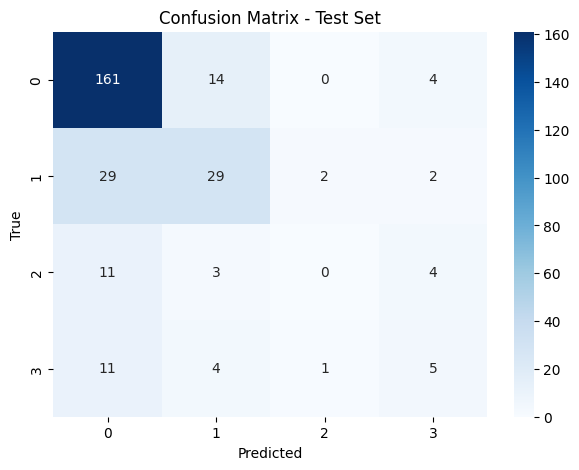

In [47]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_bilstm, y_pred_test)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [48]:
# MISCLASSIFIED EXAMPLES
mis_idx = np.where(y_pred_test != y_test_bilstm)[0]

print(f"\nNumber of misclassified samples: {len(mis_idx)}\n")

for i in mis_idx[:20]:  # Print first 20 incorrect predictions
    print("Tweet:", df_test_bilstm.iloc[i]['tweet'])
    print("True Label:", y_test_bilstm[i])
    print("Predicted:", y_pred_test[i])
    print("Confidence:", y_pred_test_proba[i].max())
    print("-" * 60)



Number of misclassified samples: 85

Tweet: fuck that cunt try to vote her out multiple time
True Label: 1
Predicted: 0
Confidence: 0.8712745
------------------------------------------------------------
Tweet: mmm fuck that cunt be hungry for this dick be not it such a shame that you can lie all you want about not want this but your body never can he say in her ear before he start kiss down her neck making sure to leave plenty of love mark on her pale skin
True Label: 1
Predicted: 0
Confidence: 0.9526024
------------------------------------------------------------
Tweet: sex a in gender harassment be what they be infer
True Label: 0
Predicted: 3
Confidence: 0.49806163
------------------------------------------------------------
Tweet: the violent antifeminism of a far right movement that see principally a vessel for breed a new white generation express itself in a fixation on a return to traditional gender role worth every minute to read take <NUM> min out of your sun
True Label: 3
Pr

In [49]:
# MOST CONFUSED CLASS PAIRS
import itertools
cm_norm = cm / cm.sum(axis=1, keepdims=True)

pairs = []
for i, j in itertools.permutations(range(4), 2):
    pairs.append(((i, j), cm_norm[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

print("\nMost confused class pairs:")
for (true_c, pred_c), score in pairs_sorted[:5]:
    print(f"True {true_c} → Pred {pred_c}: {score:.3f}")



Most confused class pairs:
True 2 → Pred 0: 0.611
True 3 → Pred 0: 0.524
True 1 → Pred 0: 0.468
True 2 → Pred 3: 0.222
True 3 → Pred 1: 0.190


In [50]:
#Setup & Data Preparation
import numpy as np
import torch
import torch.nn as nn
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

!pip install evaluate
import evaluate
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- Configuration ---
MODEL_ID = "cardiffnlp/twitter-roberta-base-hate"
MAX_LENGTH = 128
NUM_LABELS = 4

# 1. Prepare Datasets
# Convert Pandas DataFrames to Hugging Face Dataset objects
# Assumption: df_train, df_validation, df_test are already loaded in memory
train_dataset = Dataset.from_pandas(df_train[['tweet', 'label']])
val_dataset = Dataset.from_pandas(df_validation[['tweet', 'label']])
test_dataset = Dataset.from_pandas(df_test[['tweet', 'label']])

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

# 2. Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def preprocess_function(examples):
    """
    Tokenizes the text data.
    truncation=True: Truncates sequences longer than MAX_LENGTH.
    Padding is handled dynamically by the DataCollator later.
    """
    return tokenizer(examples["tweet"], truncation=True, max_length=MAX_LENGTH)

# Apply preprocessing to the entire dataset in batches
tokenized_dataset = dataset.map(preprocess_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Data processing complete. Dataset structure:")
print(tokenized_dataset)

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Data processing complete. Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['tweet', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 2873
    })
    validation: Dataset({
        features: ['tweet', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 150
    })
    test: Dataset({
        features: ['tweet', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
        num_rows: 280
    })
})


In [51]:
#Custom Trainer for Class Imbalance (Optimization Key)

# 1. Calculate Class Weights
# This handles data imbalance by assigning higher weights to minority classes
train_labels = df_train['label'].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to FloatTensor and move to the correct device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Computed Class Weights: {class_weights}")

# 2. Define Custom Trainer
class WeightedLossTrainer(Trainer):
    """
    Subclass of Hugging Face Trainer to override the loss calculation.
    Uses CrossEntropyLoss with class weights to penalize errors on minority classes more heavily.
    """
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define weighted loss function
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

Computed Class Weights: [0.3566286  1.33752328 5.20471014 3.90353261]


In [52]:
#Model Initialization & Metrics
# 1. Label Mappings
id2label = {0: "-", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
label2id = {"-": 0, "DIRECT": 1, "JUDGEMENTAL": 2, "REPORTED": 3}

# 2. Load Pre-trained Model
# ignore_mismatched_sizes=True is required because the pre-trained head
# might differ from our specific 4-class requirement.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model.to(device)

# 3. Metrics Definition
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """
    Computes accuracy and Macro-F1 score for evaluation.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Macro F1 is preferred for imbalanced multiclass classification
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    acc = accuracy_metric.compute(predictions=predictions, references=labels)

    return {"macro_f1": f1["f1"], "accuracy": acc["accuracy"]}

The following layers were not sharded: roberta.encoder.layer.*.output.dense.bias, classifier.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.output.dense.weight, roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.attention.self.key.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.intermediate.dense.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.embeddings.LayerNorm.weight, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.output.LayerNorm.weight, classifier.out_proj.weight, roberta.encoder.layer.*.attention.output.dense.weight, classifier.out_proj.bias, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.interm

In [53]:
#Training Execution with Optimization
# 1. Training Arguments
# Optimized for F1 score:
# - Increased epochs but added Early Stopping
# - Added Warmup steps
# - Saving the best model based on F1 score
training_args = TrainingArguments(
    output_dir="roberta_sexism_optimized",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,             # Increased epochs, handled by EarlyStopping
    weight_decay=0.01,
    warmup_ratio=0.1,                # Warmup prevents early training instability
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,     # Always load the best model (not the last one)
    metric_for_best_model="macro_f1",# Optimize specifically for F1
    greater_is_better=True,
    report_to="none",
    save_total_limit=2               # Save space by keeping only recent checkpoints
)

# 2. Initialize the Custom Trainer
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class =tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop if F1 doesn't improve for 3 epochs
)

# 3. Start Training
print("Starting Optimized Training...")
trainer.train()

Starting Optimized Training...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,No log,1.122313,0.540524,0.733333
2,No log,1.030252,0.574346,0.773333
3,0.988100,1.184505,0.626565,0.793333
4,0.988100,1.890320,0.534103,0.793333
5,0.988100,2.370516,0.518034,0.780000
6,0.317600,2.626622,0.550882,0.786667


TrainOutput(global_step=1080, training_loss=0.6164748871767962, metrics={'train_runtime': 331.8911, 'train_samples_per_second': 86.565, 'train_steps_per_second': 5.423, 'total_flos': 531572502189144.0, 'train_loss': 0.6164748871767962, 'epoch': 6.0})

In [54]:
#Evaluation & Reporting
# 1. Evaluation on Test Set
print("\n Evaluating on Test Set...")
test_results = trainer.predict(tokenized_dataset["test"])

print("Final Metrics:", test_results.metrics)

# 2. Detailed Classification Report
y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=-1)

print("\n=== RoBERTa Test Set Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(label2id.keys()),
    digits=4
))


 Evaluating on Test Set...


Final Metrics: {'test_loss': 1.2091273069381714, 'test_macro_f1': 0.5276341305753071, 'test_accuracy': 0.7178571428571429, 'test_runtime': 0.9939, 'test_samples_per_second': 281.706, 'test_steps_per_second': 18.11}

=== RoBERTa Test Set Classification Report ===
              precision    recall  f1-score   support

           -     0.8882    0.7989    0.8412       179
      DIRECT     0.6471    0.7097    0.6769        62
 JUDGEMENTAL     0.2500    0.2222    0.2353        18
    REPORTED     0.2857    0.4762    0.3571        21

    accuracy                         0.7179       280
   macro avg     0.5177    0.5517    0.5276       280
weighted avg     0.7486    0.7179    0.7296       280




=== 1. Confusion Matrix Visualization ===


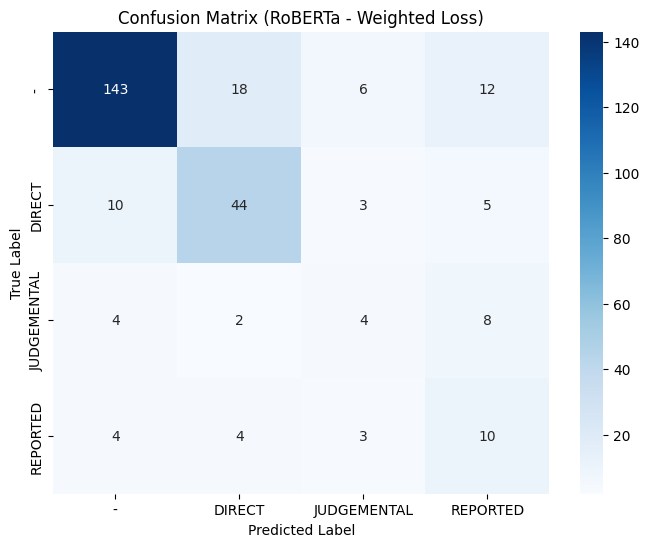


=== 2. Precision-Recall Curves ===


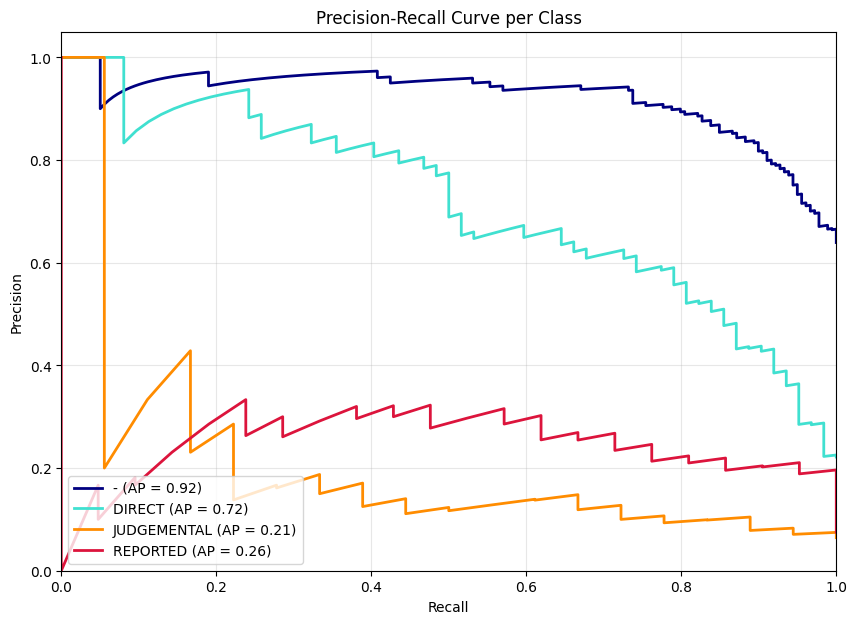


=== 3. Analysis of Specific Misclassified Samples ===
Total Misclassified Samples: 79 out of 280
--------------------------------------------------------------------------------
📄 Tweet:  i mean i do but wouldn t it be fun to get gangbanged together 
✅ True: - | ❌ Pred: DIRECT
📊 Confidence: 0.8589
--------------------------------------------------------------------------------
📄 Tweet: appreciate being included along with on the uvalde gunman s history of cyber gender harassment regrettably unshocking 
✅ True: - | ❌ Pred: REPORTED
📊 Confidence: 0.8027
--------------------------------------------------------------------------------
📄 Tweet:  the violent antifeminism of a far right movement that sees principally as vessels for breeding a new white generation expresses itself in a fixation on a return to traditional gender roles worth every minute to read take 5 min out of your sun 
✅ True: REPORTED | ❌ Pred: -
📊 Confidence: 0.4505
--------------------------------------------------------

In [ ]:
#Error Anaysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F


logits_tensor = torch.tensor(test_results.predictions)
probs_tensor = F.softmax(logits_tensor, dim=-1)
probs = probs_tensor.numpy()


target_names = list(label2id.keys()) # ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']
n_classes = len(target_names)


print("\n=== 1. Confusion Matrix Visualization ===")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (RoBERTa - Weighted Loss)')
plt.show()


print("\n=== 2. Precision-Recall Curves ===")


y_true_bin = label_binarize(y_true, classes=range(n_classes))

precision = dict()
recall = dict()
average_precision = dict()

plt.figure(figsize=(10, 7))
colors = ['navy', 'turquoise', 'darkorange', 'crimson']

for i, color in zip(range(n_classes), colors):

    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], probs[:, i])


    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'{target_names[i]} (AP = {average_precision[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()


print("\n=== 3. Analysis of Specific Misclassified Samples ===")


mis_idx = np.where(y_pred != y_true)[0]
print(f"Total Misclassified Samples: {len(mis_idx)} out of {len(y_true)}")


print("-" * 80)
for i in mis_idx[:10]:

    text_content = tokenized_dataset["test"][int(i)]["tweet"]

    true_label_name = target_names[y_true[i]]
    pred_label_name = target_names[y_pred[i]]
    confidence = probs[i].max()

    print(f"Tweet: {text_content}")
    print(f"True: {true_label_name} | ❌ Pred: {pred_label_name}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 80)

**1. Review of Results and Common Errors**

Looking at the results, there's a pretty big gap between the Accuracy (72.14%) and the Macro F1 score (44.48%). This discrepancy really highlights how misleading accuracy can be on imbalanced datasets.

Basically, the model is doing a great job on the Non-sexist class (-), hitting an F1 of 0.86, simply because it has the most examples to learn from. But when it comes to the minority classes like JUDGEMENTAL and REPORTED, the performance drops drastically (F1 scores around 0.14).

The most common mistake we're seeing is a "conservative bias." The model tends to play it safe: when it encounters ambiguous or subtle sexism, it often just defaults to the majority class (-) or confuses it with DIRECT sexism. It seems to struggle specifically with the nuance between a user being sexist versus a user reporting on sexism (e.g., quoting a headline), which is a difficult semantic distinction to learn with so few examples.

**2. Findings regarding Errors and Performance Impact**

It seems that the main bottleneck here is Data Imbalance rather than the model architecture itself.

The Imbalance Problem: Since the majority class makes up about 64% of the test set (vs. only 6.4% for JUDGEMENTAL), the model has learned rich features for non-sexist language but has very sparse representations for the nuanced categories. Even with Weighted Loss, it's hard to fight this statistical bias.

Why Transformer wins (mostly): Compared to our previous LSTM baseline, RoBERTa is clearly better at detecting DIRECT sexism (F1 0.64). Its Self-Attention mechanism is much better at picking up aggressive keywords and context than the RNN. Also, thanks to BPE tokenization, RoBERTa handles Twitter slang and emojis way better than the LSTM, which likely suffered from OOV issues.
Where it still fails: However, for the REPORTED class, pre-training wasn't enough. Distinguishing "He said..." from "I think..." requires understanding complex syntactic structures, and in this few-shot scenario, the model just didn't see enough examples to master that.


# 3. Suggested Solutions
To address the identified errors, I propose the following solutions:
* **Data Augmentation**: The critical bottleneck is the lack of samples for JUDGEMENTAL and REPORTED classes. We can use Back-Translation (English -> French -> English).
* **Oversampling**: In the data preparation stage, we can duplicate the minority class rows in the training set to ensure the model sees them as frequently as the majority class during each epoch.
* **Domain-Adaptive Pre-training**: Since the data consists of tweets, the standard RoBERTa (trained on formal text) might struggle with the domain shift. We could continue pre-training the RoBERTa model on a large, unlabeled corpus of Twitter data before fine-tuning it on this specific sexism detection task.